In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

_here = Path(os.path.abspath(""))
while not (_here / "pixi.toml").exists():
    _here = _here.parent
    if _here == _here.parent:
        raise RuntimeError("Could not find repo root")
os.chdir(_here)

In [3]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiments_analysis.sensitivity_analysis_pipeline import (
    make_config,
    run_sensitivity_analysis_multi_seed,
)

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [4]:
BASELINES_PATH = "experiments/benchmark_output_files/sensitivity_analysis/hln_baselines.yaml"
RUNS_PATH = "experiments/benchmark_output_files/sensitivity_analysis/hln_subsample.yaml"
cfg = make_config(BASELINES_PATH, RUNS_PATH)
output_dir = cfg["output_dir"]
figures_output_dir = Path(cfg["figures_output_dir"])
figures_output_dir.mkdir(exist_ok=True, parents=True)
Path(output_dir).mkdir(parents=True, exist_ok=True)

In [5]:
run_sensitivity_analysis_multi_seed(cfg)

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:243: UserWarning: NaN inf in the following destriped data: ['collapse_label']
  warn(f"NaN inf in the following destriped data: {list_nan}")


,name,converged
0,seed_42__pct_80,True
1,seed_42__pct_50,True
2,seed_42__pct_25,True
3,seed_42__pct_10,True
4,seed_42__pct_1,True
5,seed_64__pct_80,True
6,seed_64__pct_50,True
7,seed_64__pct_25,True
8,seed_64__pct_10,True
9,seed_64__pct_1,True


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)


2SN 0
b2c-sym-c_mean 1
bin_level_normalization 2
collapse_label 3
dividing_99_quantile 4
original 5
ours 6
seed_42__pct_1 7
seed_42__pct_10 8
seed_42__pct_25 9
seed_42__pct_50 10
seed_42__pct_80 11
seed_64__pct_1 12
seed_64__pct_10 13
seed_64__pct_25 14
seed_64__pct_50 15
seed_64__pct_80 16
seed_754__pct_1 17
seed_754__pct_10 18
seed_754__pct_25 19
seed_754__pct_50 20
seed_754__pct_80 21


## Global structure analysis plots

In [5]:
from pathlib import Path as P

global_structure_analysis_folder = P(output_dir) / "global_structure_analysis"

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:873: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/sensitivity_analysis_pipeline.py:892: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticklabels(), rotation=45, ha="right")


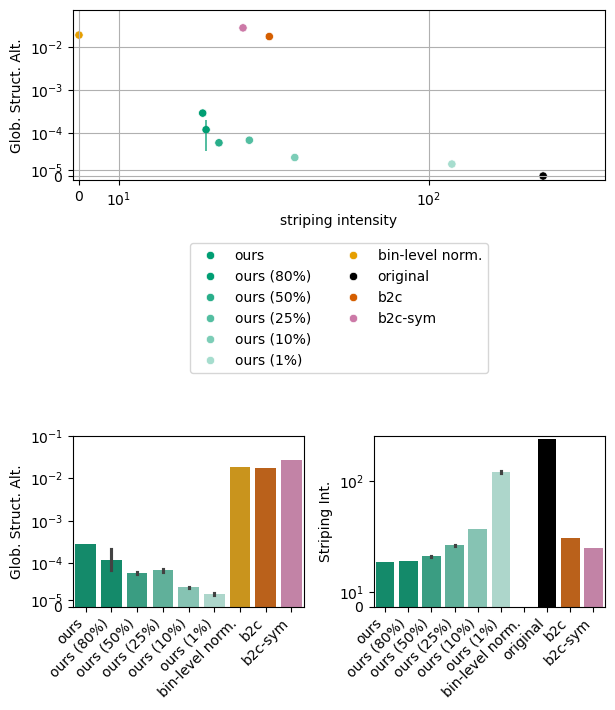

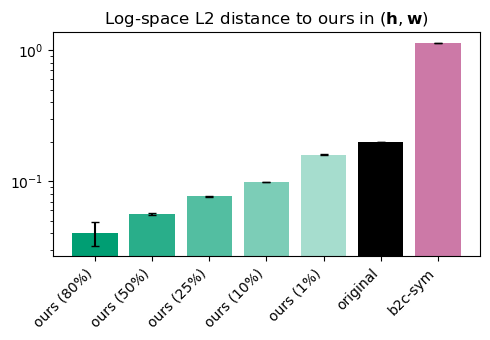

In [6]:
from src.experiments_analysis.sensitivity_analysis_pipeline import real_data_plots

real_data_plots(output_dir, figures_output_dir, "subsample")

<string>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


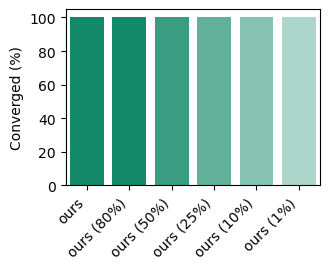

In [8]:
from src.experiments_analysis.sensitivity_analysis_pipeline import convergence_barplot

ax = convergence_barplot(output_dir, experiment_type="subsample")
plt.show()

## Chosen alpha per model

In [11]:
from src.experiments_analysis.sensitivity_analysis_pipeline import print_chosen_alphas

print_chosen_alphas(RUNS_PATH)

Chosen alpha:
seed         42        64        754
run                                 
pct_1   0.001000  0.001000  0.001000
pct_10  0.000215  0.000215  0.000215
pct_25  0.000046  0.000046  0.000046
pct_50  0.000046  0.000046  0.000046
pct_80  0.000046  0.000010  0.000046

Boundary hit wrt full CV grid (MIN / MAX / ok):
seed   42   64  754
run                
pct_1   ok   ok  ok
pct_10  ok   ok  ok
pct_25  ok   ok  ok
pct_50  ok   ok  ok
pct_80  ok  MIN  ok


,run,seed,alpha,grid_min,grid_max,boundary_side
0,pct_80,42,0.000046,0.00001,10.0,ok
1,pct_50,42,0.000046,0.00001,10.0,ok
2,pct_25,42,0.000046,0.00001,10.0,ok
3,pct_10,42,0.000215,0.00001,10.0,ok
4,pct_1,42,0.001000,0.00001,10.0,ok
5,pct_80,64,0.000010,0.00001,10.0,MIN
6,pct_50,64,0.000046,0.00001,10.0,ok
7,pct_25,64,0.000046,0.00001,10.0,ok
8,pct_10,64,0.000215,0.00001,10.0,ok
9,pct_1,64,0.001000,0.00001,10.0,ok
